In [171]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=500, noise=0.1,)

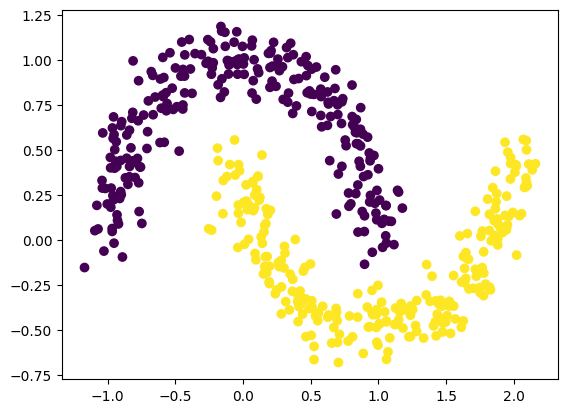

In [172]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0],X[:,1],c=y)

In [173]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [174]:
import tensorflow
from tensorflow.keras.layers import Dense
from tensorflow.keras import Sequential

In [175]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_70 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_72 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [176]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [192]:
# to calulate time 
import time
start_time = time.time()
history = model.fit(X_train,y_train,epochs=100,validation_split=0.2)
end_time = time.time()
print('The time take in this process without Batch Normalization is',(end_time-start_time))

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9531 - loss: 0.1248 - val_accuracy: 0.9250 - val_loss: 0.1615
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9531 - loss: 0.1188 - val_accuracy: 0.9250 - val_loss: 0.1542
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9594 - loss: 0.1145 - val_accuracy: 0.9375 - val_loss: 0.1471
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9594 - loss: 0.1101 - val_accuracy: 0.9250 - val_loss: 0.1425
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9594 - loss: 0.1038 - val_accuracy: 0.9375 - val_loss: 0.1336
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9656 - loss: 0.0995 - val_accuracy: 0.9375 - val_loss: 0.1297
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9688 - loss: 0.0950 - val_accuracy: 0.9375 - val_loss: 0.1218
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9688 - loss: 0.0904 - val_accuracy: 0.93

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


<Axes: title={'center': 'Without Batch Normalization'}>

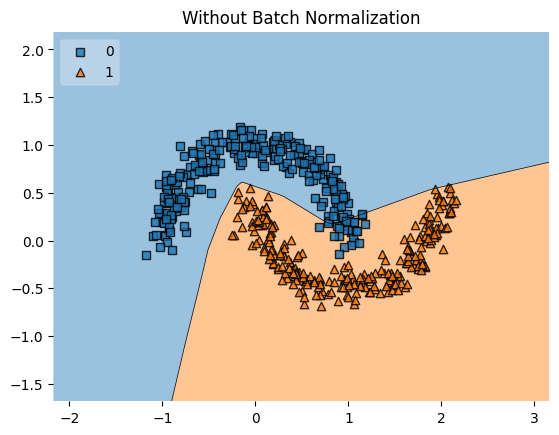

In [178]:
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt
plt.title('Without Batch Normalization')
plot_decision_regions(X, y, clf=model, legend=2)

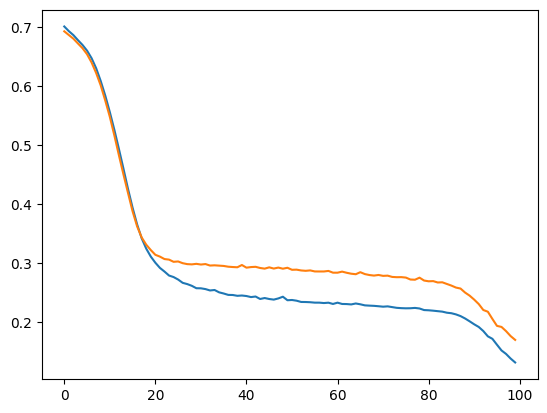

In [179]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

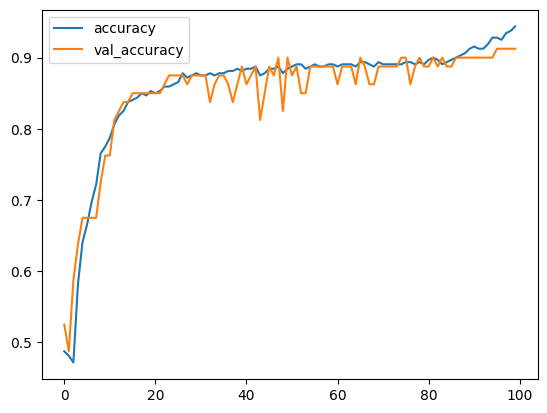

In [180]:
plt.plot(history.history['accuracy'],label='accuracy')
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.legend()

In [181]:
y_eval = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [182]:
y_pred = (y_eval >= 0.5 )

In [183]:
from sklearn.metrics import accuracy_score 
accuracy_score(y_test, y_pred)

0.99

# Accuracy without Batch_Normalization 99%

# Batch Normalization

In [184]:
from tensorflow.keras.layers import BatchNormalization

In [185]:
model_1 = Sequential()

model_1.add(Dense(10,activation='relu',input_dim=2))
model_1.add(BatchNormalization())
model_1.add(Dense(10,activation='relu'))
model_1.add(BatchNormalization())
model_1.add(Dense(10,activation='relu'))
model_1.add(BatchNormalization())
model_1.add(Dense(10,activation='relu'))
model_1.add(BatchNormalization())
model_1.add(Dense(1,activation='sigmoid'))

model_1.summary()

# γ              
# β              
# Moving mean    
# Moving variance

#It have 4 extra parameters 
#γ and β are learnable parameters; 
# moving mean and moving variance are non-trainable state values maintained by BatchNorm.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_75 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 531 (2.07 KB)

 Trainable params: 451 (1.76 KB)

 Non-trainable params: 80 (320.00 B)

In [186]:
model_1.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [193]:
# to calulate time 
start_time_with_normala = time.time()
history_with_batch_normalization = model_1.fit(X_train,y_train,epochs=100,validation_split=0.2)
end_time_with_normal = time.time()
print('The time take in this process with Batch Normalization is',(end_time_with_normal-start_time_with_normala))

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0104 - val_accuracy: 1.0000 - val_loss: 0.0024
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0130 - val_accuracy: 1.0000 - val_loss: 0.0021
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9969 - loss: 0.0174 - val_accuracy: 1.0000 - val_loss: 0.0021
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9969 - loss: 0.0168 - val_accuracy: 1.0000 - val_loss: 0.0027
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0129 - val_accuracy: 1.0000 - val_loss: 0.0021
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9969 - loss: 0.0091 - val_accuracy: 1.0000 - val_loss: 0.0017
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0061 - val_accuracy: 1.0000 - val_loss: 0.0016
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9906 - loss: 0.0209 - val_accuracy: 1.

In [188]:
y_eval_with_batch_normalization = model_1.predict(X_test)
y_pred_with_batch_normalization = (y_eval_with_batch_normalization >= 0.5 )
from sklearn.metrics import accuracy_score 
accuracy_score(y_test, y_pred_with_batch_normalization)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


1.0

# Accuracy with batch normalization 100%

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


<Axes: title={'center': 'With Batch Normalization'}>

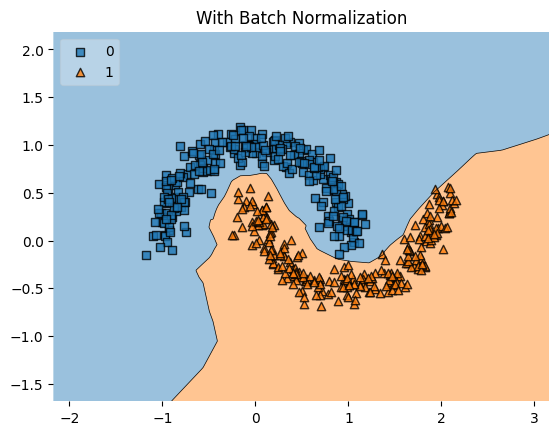

In [189]:
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt
plt.title('With Batch Normalization')
plot_decision_regions(X, y, clf=model_1, legend=2)

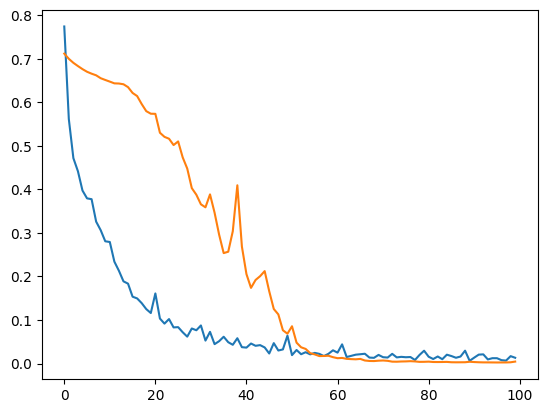

In [190]:
plt.plot(history_with_batch_normalization.history['loss'])
plt.plot(history_with_batch_normalization.history['val_loss'])

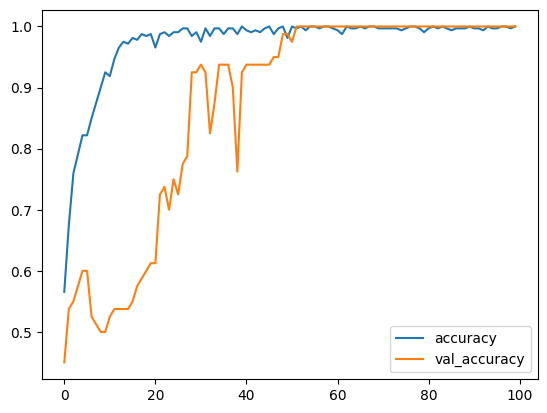

In [191]:
plt.plot(history_with_batch_normalization.history['accuracy'],label='accuracy')
plt.plot(history_with_batch_normalization.history['val_accuracy'],label='val_accuracy')
plt.legend()